In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import io
import matplotlib.dates as mdates
import datetime

DATOS VALLADOLID

In [3]:
df = pd.read_csv(r'C:\Users\USUARIO\Documents\TFG_ALTURA\evolucion_predicciones\semana_valladolid\resultados_231757\predicciones_detalladas.txt', sep=r'\s*\|\s*', engine='python', skiprows=[1])

df.columns = df.columns.str.strip()

# real = df['Real (m)']
# predicho = df['Predicho (m)']
# error = df['Error (m)']
nombre=df['Nombre de Imagen']

#Separo la información del nombre de la imagen en días y horas
partes_nombre = nombre.str.split('_', expand=True)

fecha = partes_nombre[1]        # '20240224'
tiempo_ext = partes_nombre[2]   # '2034.jpg'

# Quitamos el .jpg
tiempo = tiempo_ext.str.replace('.jpg', '', regex=False) # Divide según el punto y el .jpg lo sustituye por texto en blanco

df['Fecha_Completa'] = pd.to_datetime(fecha + tiempo, format='%Y%m%d%H%M')
df = df.sort_values(by='Fecha_Completa')


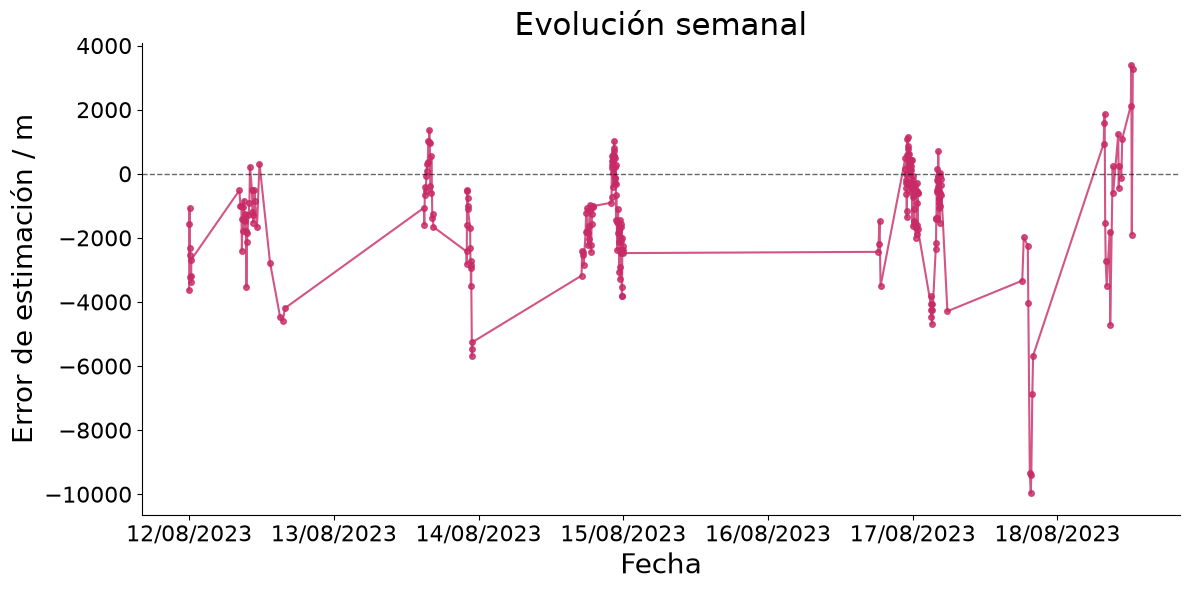

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))


ax.plot(df['Fecha_Completa'], df['Error (m)'], color='#C72A66', marker='o', markersize=4, linestyle='-', linewidth=1.5, alpha=0.8)
# Línea de referencia en el 0
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)


ax.set_ylabel('Error de estimación / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)

#formato_fecha = mdates.DateFormatter('%d/%m/%Y %H:%M')
formato_fecha = mdates.DateFormatter('%d/%m/%Y')
ax.xaxis.set_major_formatter(formato_fecha)

# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.title('Evolución semanal', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

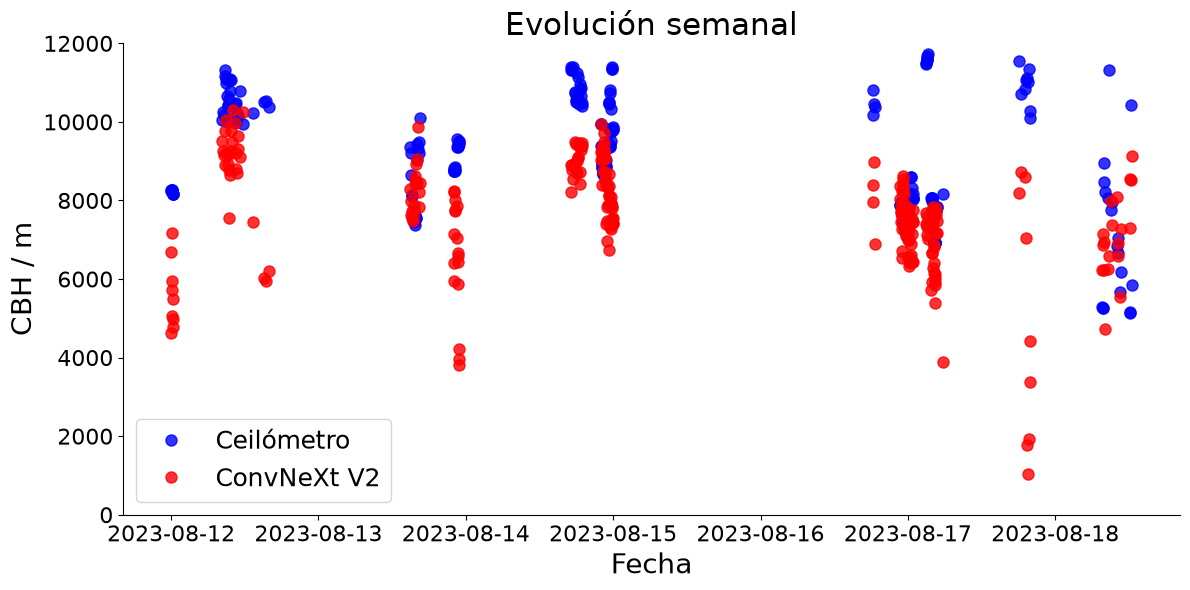

In [5]:
######### REPRESENTACIÓN SEMANA ##############

fig, ax = plt.subplots(figsize=(12, 6))


ax.plot(df['Fecha_Completa'], df['Real (m)'], color='blue', linestyle='none', marker='o', markersize=8, alpha=0.8, label='Ceilómetro')
ax.plot(df['Fecha_Completa'], df['Predicho (m)'], color='red', linestyle='none', marker='o', markersize=8, alpha=0.8, label='ConvNeXt V2')

# Línea de referencia en los límites de cada tipo de nube
# ax.axhline(2000, color='black', linestyle='--', linewidth=1, alpha=0.6)
# ax.axhline(6000, color='black', linestyle='--', linewidth=1, alpha=0.6)


ax.set_ylabel('CBH / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)

# formato_fecha = mdates.DateFormatter('%H:%M')

# ax.xaxis.set_major_formatter(formato_fecha)
plt.ylim(0,12000)
# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=18, loc='lower left')
plt.title('Evolución semanal', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
datos_por_dia = df['Fecha_Completa'].dt.date.value_counts().sort_index()

print("Número de datos por día:")
print(datos_por_dia)

Número de datos por día:
Fecha_Completa
2023-08-12    39
2023-08-13    36
2023-08-14    73
2023-08-16    39
2023-08-17    64
2023-08-18    19
Name: count, dtype: int64


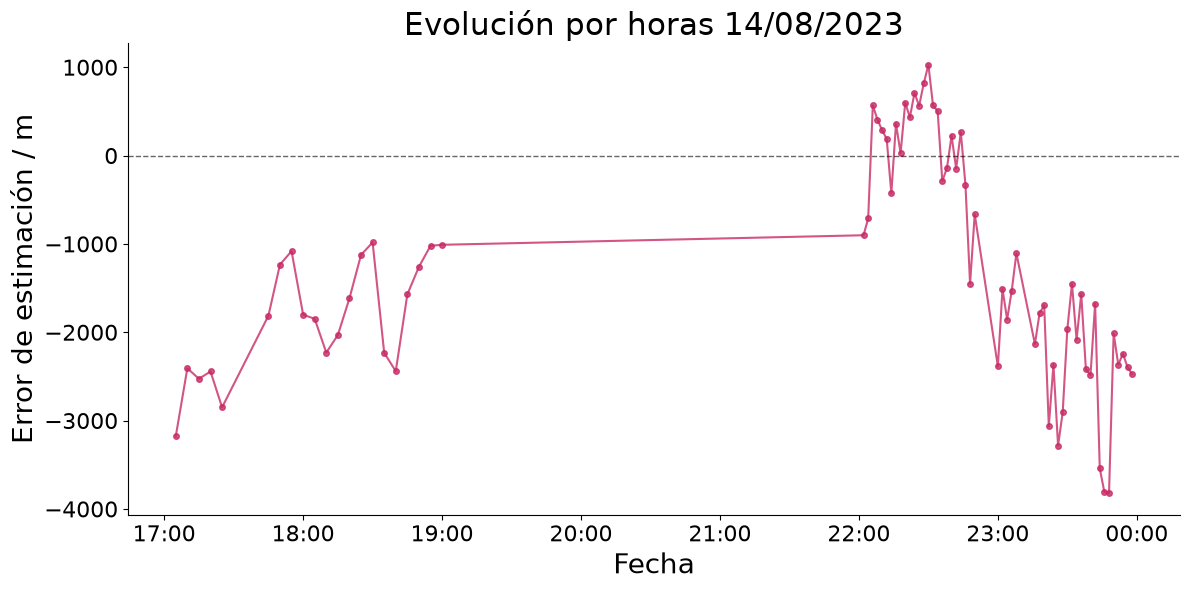

In [7]:
######### REPRESENTACIÓN DE UN SOLO DÍA ##############

dia = datetime.date(2023,8,14)

# Nuevo data frame
df_dia = df[df['Fecha_Completa'].dt.date == dia]


fig, ax = plt.subplots(figsize=(12, 6))


ax.plot(df_dia['Fecha_Completa'], df_dia['Error (m)'], color='#C72A66', marker='o', markersize=4, linestyle='-', linewidth=1.5, alpha=0.8)
# Línea de referencia en el 0
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)


ax.set_ylabel('Error de estimación / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)

formato_fecha = mdates.DateFormatter('%H:%M')

ax.xaxis.set_major_formatter(formato_fecha)

# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.title('Evolución por horas 14/08/2023', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

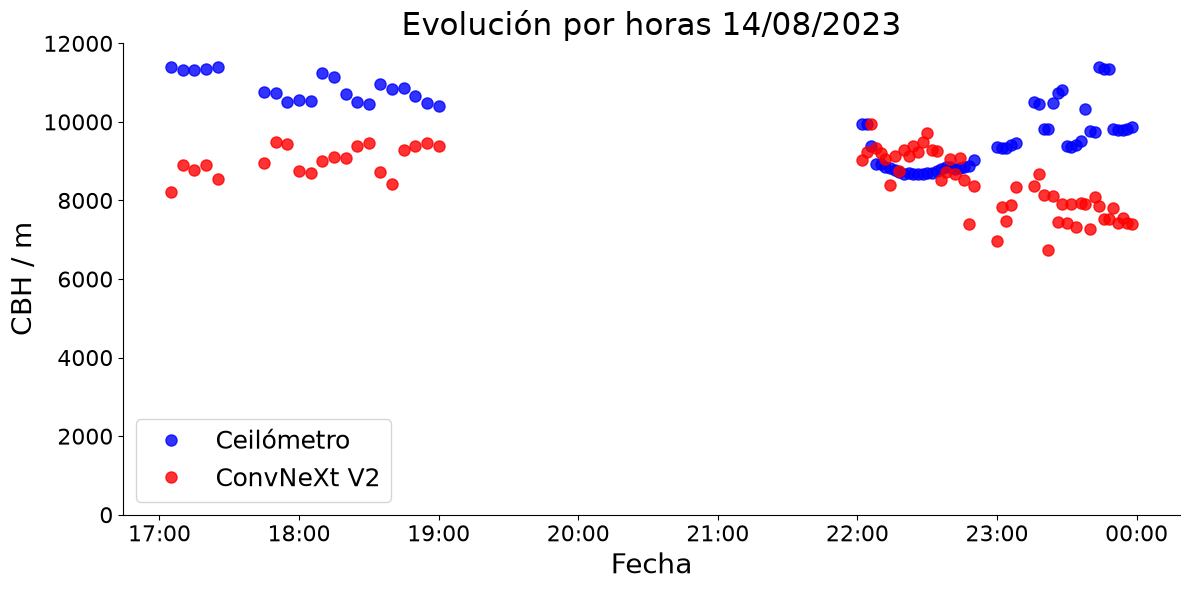

In [8]:
######### REPRESENTACIÓN DE UN SOLO DÍA ##############

dia = datetime.date(2023,8,14)

# Nuevo data frame
df_dia = df[df['Fecha_Completa'].dt.date == dia]


fig, ax = plt.subplots(figsize=(12, 6))


ax.plot(df_dia['Fecha_Completa'], df_dia['Real (m)'], color='blue', linestyle='none', marker='o', markersize=8, alpha=0.8, label='Ceilómetro')
ax.plot(df_dia['Fecha_Completa'], df_dia['Predicho (m)'], color='red', linestyle='none', marker='o', markersize=8, alpha=0.8, label='ConvNeXt V2')

# Línea de referencia en los límites de cada tipo de nube
# ax.axhline(2000, color='black', linestyle='--', linewidth=1, alpha=0.6)
# ax.axhline(6000, color='black', linestyle='--', linewidth=1, alpha=0.6)
plt.ylim(0,12000)

ax.set_ylabel('CBH / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)

formato_fecha = mdates.DateFormatter('%H:%M')

ax.xaxis.set_major_formatter(formato_fecha)

# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=18, loc='lower left')
plt.title('Evolución por horas 14/08/2023', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

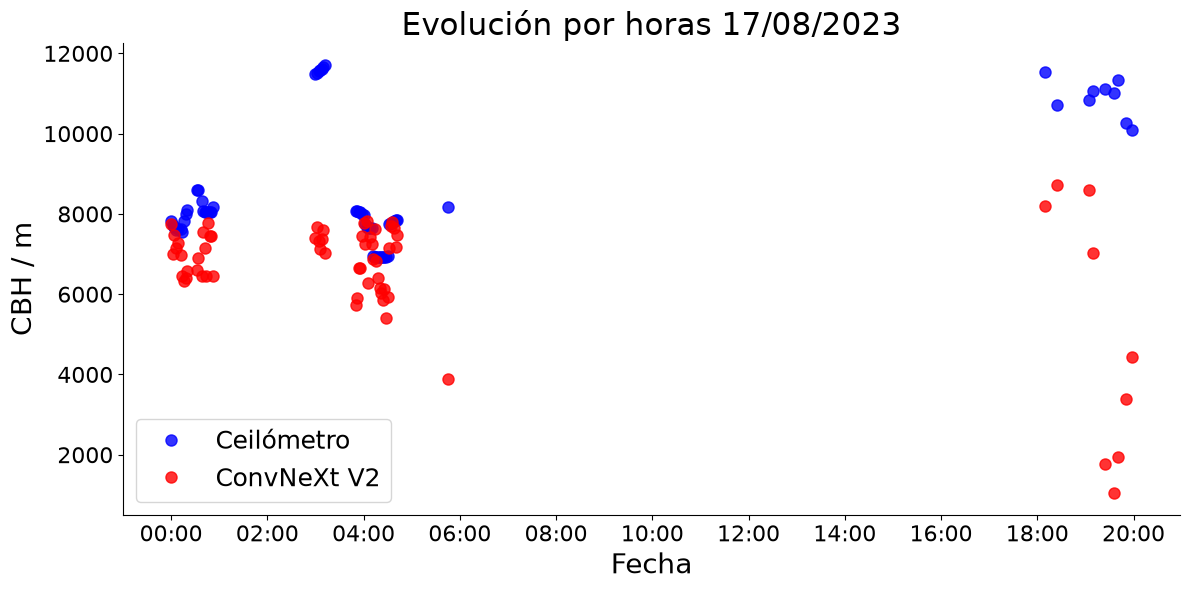

In [9]:
######### REPRESENTACIÓN DE UN SOLO DÍA ##############

dia = datetime.date(2023,8,17)

# Nuevo data frame
df_dia = df[df['Fecha_Completa'].dt.date == dia]


fig, ax = plt.subplots(figsize=(12, 6))


ax.plot(df_dia['Fecha_Completa'], df_dia['Real (m)'], color='blue', linestyle='none', marker='o', markersize=8, alpha=0.8, label='Ceilómetro')
ax.plot(df_dia['Fecha_Completa'], df_dia['Predicho (m)'], color='red', linestyle='none', marker='o', markersize=8, alpha=0.8, label='ConvNeXt V2')

# Línea de referencia en los límites de cada tipo de nube
# ax.axhline(2000, color='black', linestyle='--', linewidth=1, alpha=0.6)
# ax.axhline(6000, color='black', linestyle='--', linewidth=1, alpha=0.6)


ax.set_ylabel('CBH / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)

formato_fecha = mdates.DateFormatter('%H:%M')

ax.xaxis.set_major_formatter(formato_fecha)

# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=18, loc='lower left')
plt.title('Evolución por horas 17/08/2023', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

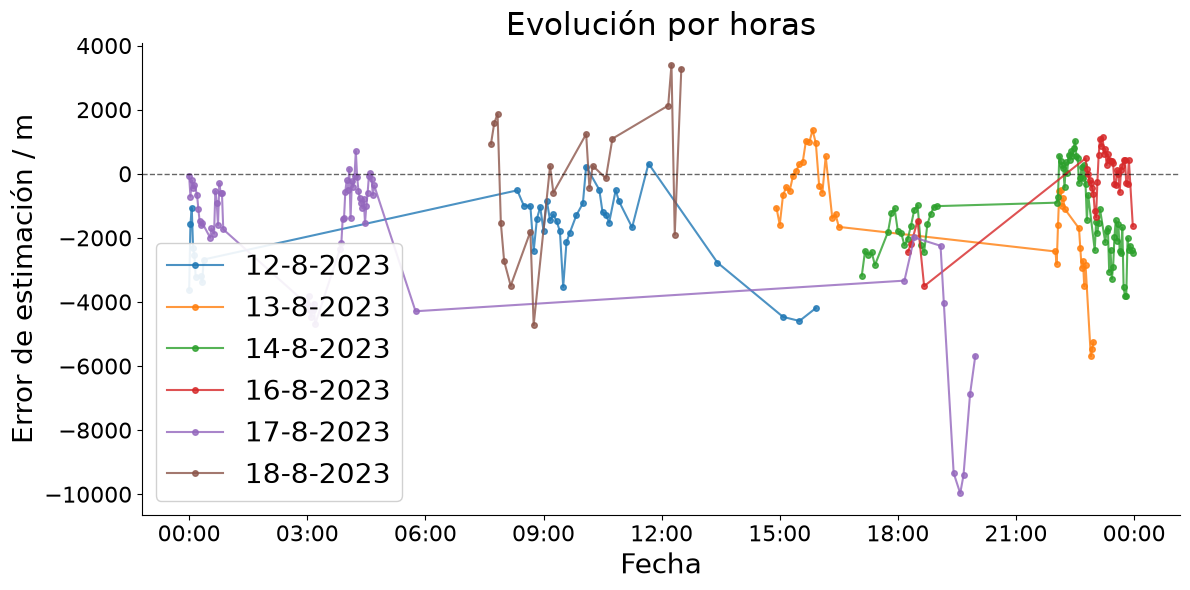

In [10]:
######### REPRESENTACIÓN DE UN SOLO DÍA ##############

dias = df['Fecha_Completa'].dt.date.sort_index()
lista_dias = sorted(list(set(dias)))

fig, ax = plt.subplots(figsize=(12, 6))

for dia in lista_dias:
    # if dia == datetime.date(2024,10,26):
    #     continue
    # Nuevo data frame
    df_dia = df[df['Fecha_Completa'].dt.date == dia]
    fecha_auxiliar = pd.to_datetime(df_dia['Fecha_Completa'].dt.strftime('2000-01-01 %H:%M:%S')) #ponemos a todos los días la misma fecha para que colapsen en el plot
    ax.plot(fecha_auxiliar, df_dia['Error (m)'], marker='o', markersize=4, linestyle='-', linewidth=1.5, alpha=0.8, label=f'{dia.day}-{dia.month}-{dia.year}')



# Línea de referencia en el 0
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)


ax.set_ylabel('Error de estimación / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)

formato_fecha = mdates.DateFormatter('%H:%M')

ax.xaxis.set_major_formatter(formato_fecha)

# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.title('Evolución por horas', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(loc='lower left', framealpha=0.9, facecolor='white', fontsize=20)

plt.tight_layout()
plt.show()